# Step 1.2: Subnational Population & Density 2019 (World Bank / NIS)
### Normalizing Per-Capita Metrics and Evaluating Store Catchment Areas
**Project:** Cambodia MSE Intelligence  
**Department:** Department of Applied Mathematics and Statistics, Institute of Technology of Cambodia (ITC)  
**Data Source:** National Institute of Statistics (NIS) / World Bank Cambodia Population Census 2019.  
**Objective:** Load provincial population and density statistics to normalize per-capita business metrics, evaluate store catchment populations across rural vs urban areas, and identify primary consumer demand clusters.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pop_path = os.path.join('..', '..', 'data', 'Cambodia Population 2019.xlsx')
df_pop = pd.read_excel(pop_path, sheet_name="Data", header=3).dropna(subset=["Province"])
df_pop = df_pop[df_pop["Province"] != "Total"].copy()
df_pop["Population"] = pd.to_numeric(df_pop["Population"])
df_pop["Density"] = pd.to_numeric(df_pop["Population Density"])
df_pop["national_pop_share_pct"] = (df_pop["Population"] / df_pop["Population"].sum()) * 100
df_pop["catchment_5km_pop"] = (df_pop["Density"] * (np.pi * 5**2)).round(0)
df_pop = df_pop.sort_values(by="Population", ascending=False).reset_index(drop=True)

print(f"Total Provinces: {len(df_pop)}")
print(f"Total Census Population: {df_pop['Population'].sum():,.0f}")
df_pop[['Province', 'Population', 'Density', 'national_pop_share_pct', 'catchment_5km_pop']].head(10)

Total Provinces: 30
Total Census Population: 15,288,489
           Province  Population  Density  national_pop_share_pct  catchment_5km_pop
0        Phnom Penh   2129371.0   3136.0               13.927936           246301.0
1            Kandal   1195547.0    376.0                7.819916            29531.0
2         Prey Veng   1057428.0    217.0                6.916498            17043.0
3         Siem Reap   1006512.0     98.0                6.583463             7697.0
4        Battambang    987400.0     84.0                6.458454             6597.0
5             Takeo    899485.0    252.0                5.883413            19792.0
6      Kampong Cham    895763.0    197.0                5.859068            15472.0
7      Kampong Speu    872219.0    124.0                5.705070             9739.0
8  Banteay Meanchey    859545.0    129.0                5.622171            10132.0
9       Tbong Khmun    775296.0    148.0                5.071109            11624.0

### 2.1 Provincial Consumer Market Sizing
Top 10 provinces by total population, representing the primary consumer base.

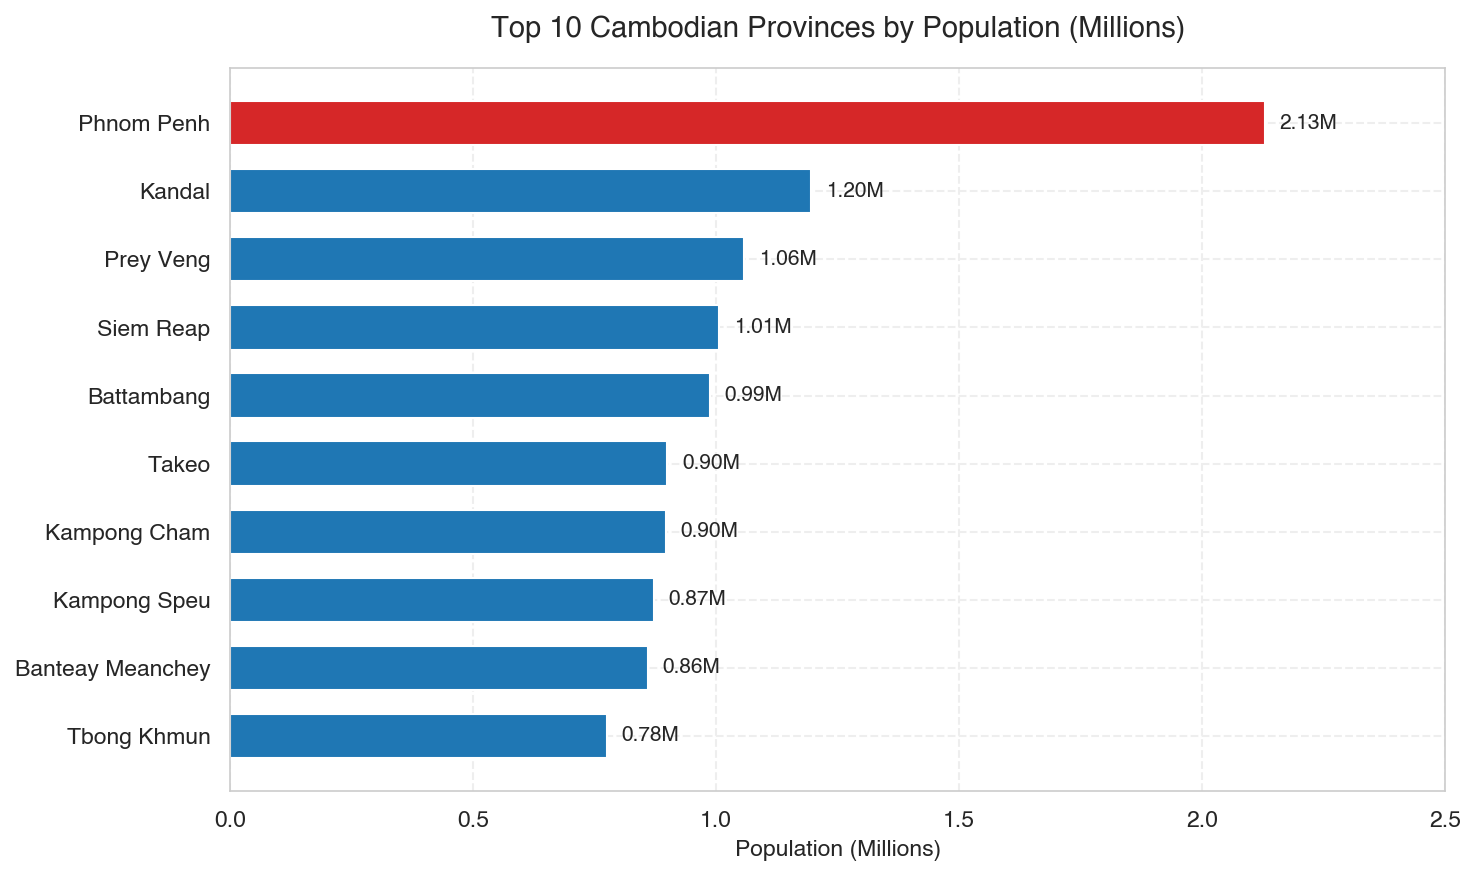

In [ ]:
# Top 10 Provinces Bar Chart
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
top10 = df_pop.head(10).sort_values("Population", ascending=True)
colors = ['#1f77b4' if p != 'Phnom Penh' else '#d62728' for p in top10['Province']]
bars = ax.barh(top10['Province'], top10['Population'] / 1e6, color=colors, height=0.65)
ax.set_title("Top 10 Cambodian Provinces by Population (Millions)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Population (Millions)")
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.03, bar.get_y() + bar.get_height()/2, f"{w:.2f}M", va='center', fontweight='bold')
ax.set_xlim(0, 2.5)
plt.show()

### 2.2 Store Catchment Area Analysis (5km Radius)
Estimated reachable consumer density within a 5km urban radius based on provincial density.

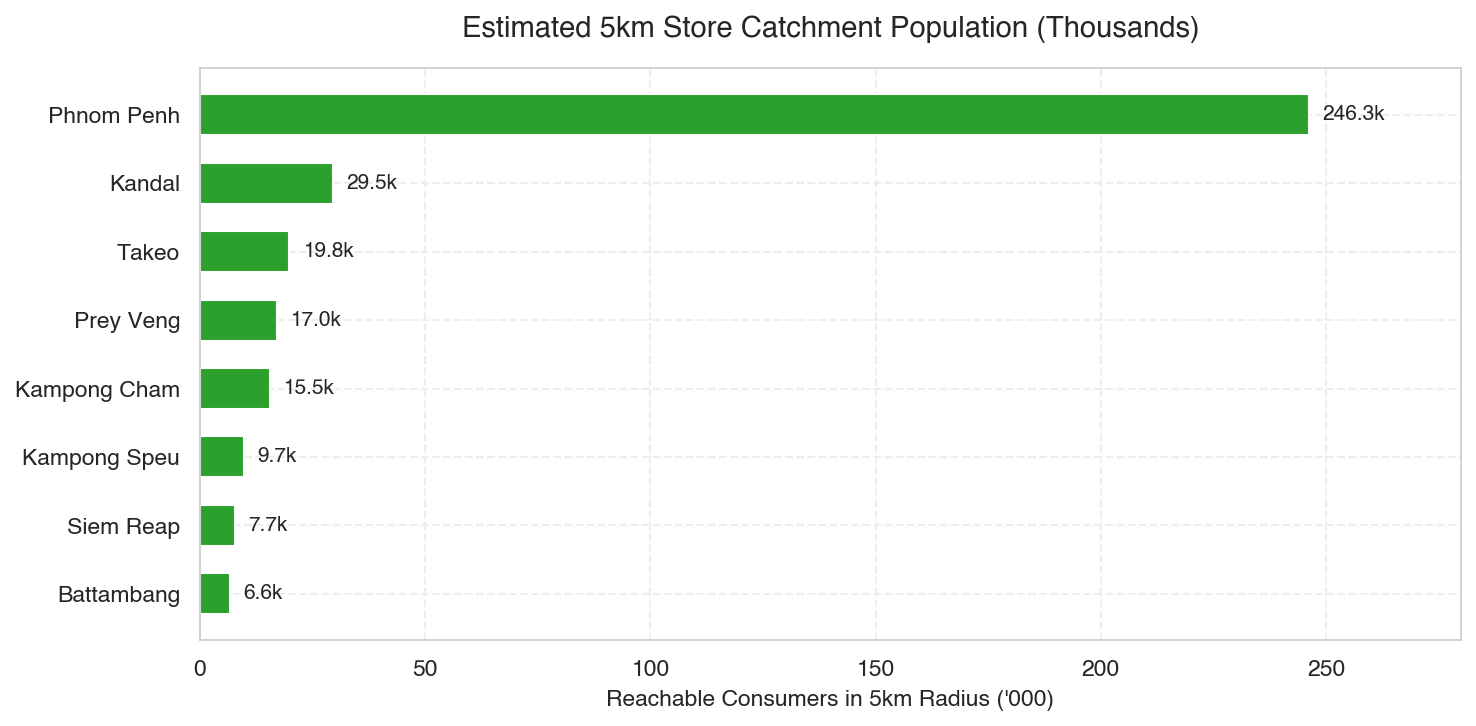

In [ ]:
# Store Catchment Population (5km radius)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
top_catchment = df_pop.head(8).sort_values("catchment_5km_pop", ascending=True)
bars = ax.barh(top_catchment["Province"], top_catchment["catchment_5km_pop"] / 1000, color="#2ca02c", height=0.6)
ax.set_title("Estimated 5km Store Catchment Population (Thousands)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Reachable Consumers in 5km Radius ('000)")
for bar in bars:
    w = bar.get_width()
    ax.text(w + 3, bar.get_y() + bar.get_height()/2, f"{w:,.1f}k", va='center', fontweight='bold')
ax.set_xlim(0, 280)
plt.show()

### 2.3 Spatial Clustering: Population vs. Density
Segmenting Cambodia into Hyper-Dense Metro (Phnom Penh), High Density Agrarian (Kandal, Prey Veng, Takeo), and Regional Hubs.

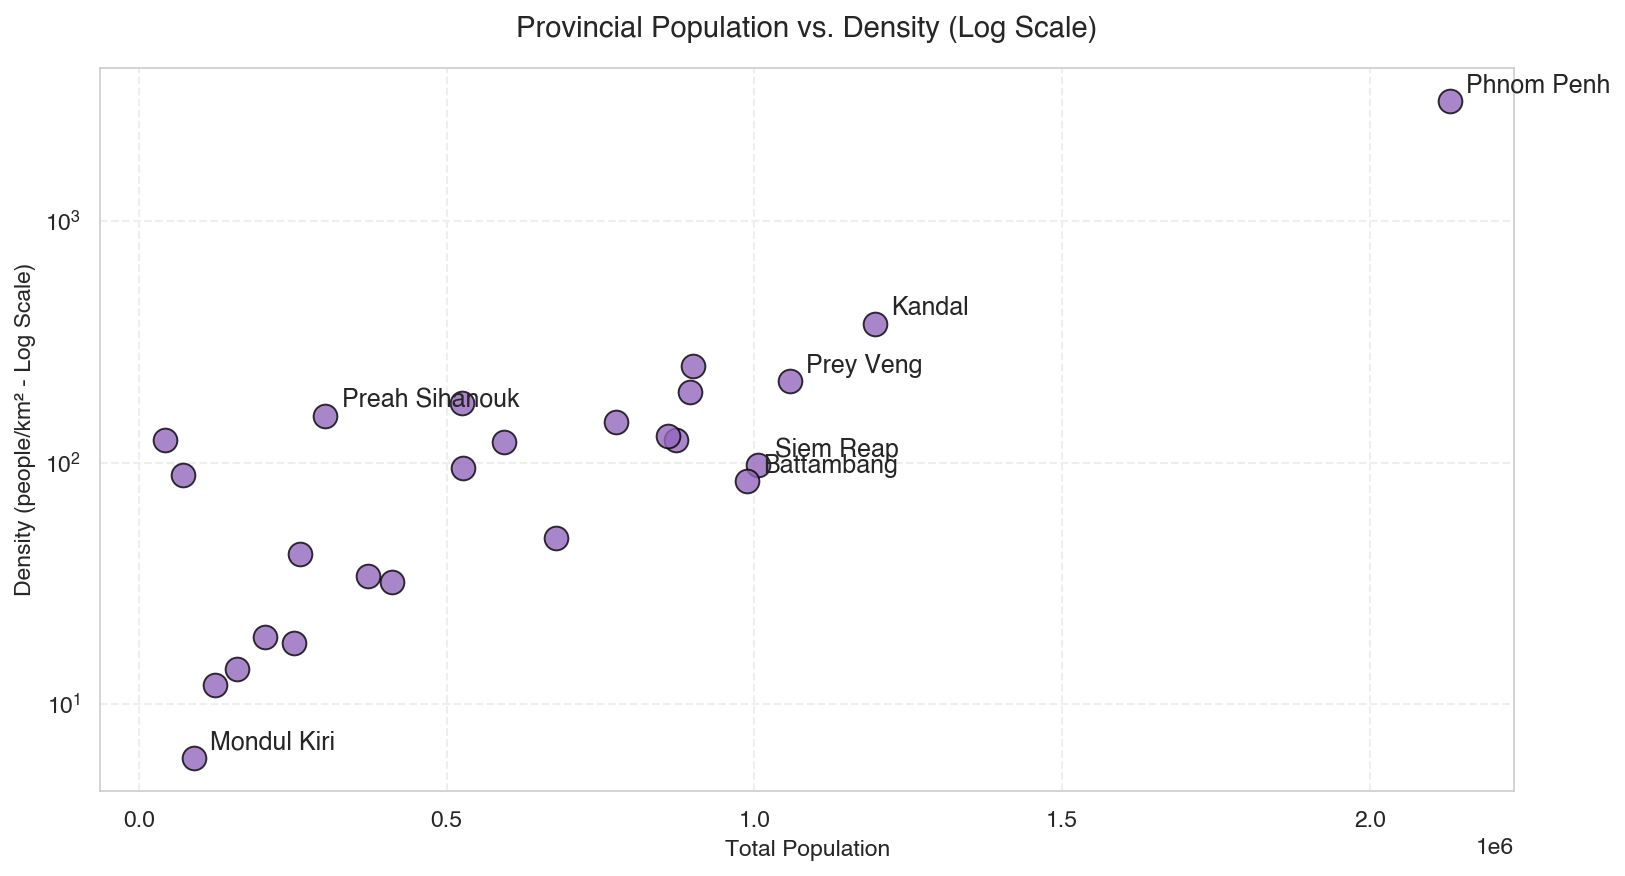

In [ ]:
# Population vs Density Clustering
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(data=df_pop, x="Population", y="Density", s=130, color="#9467bd", alpha=0.8, edgecolor='black', ax=ax)
ax.set_yscale('log')
ax.set_title("Provincial Population vs. Density (Log Scale)", fontsize=14, fontweight='bold', pad=15)
for _, r in df_pop.iterrows():
    if r["Province"] in ["Phnom Penh", "Kandal", "Prey Veng", "Siem Reap", "Battambang", "Preah Sihanouk", "Mondul Kiri"]:
        ax.annotate(r["Province"], (r["Population"], r["Density"]), xytext=(8, 4), textcoords="offset points", fontweight='bold')
plt.show()

### Step 1.2 Findings for Per-Capita Normalization & Catchments
1. **Extreme Catchment Asymmetry:** A physical retail MSE in Phnom Penh has a theoretical 5km catchment population of **~246,000 people**, whereas in Battambang it is **~6,600 people**, and in rural Mondul Kiri it is **under 500 people**.
2. **Per-Capita Metric Baseline:** The 15.29M national census allows normalizing retail store density per 10,000 residents across provinces to identify underserved markets.
